<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [7]</a>'.</span>

# 06 — Policy comparison: baseline vs distilled

Сравнение action distributions и поведенческих метрик между:
- **Baseline** SmolVLA (`HuggingFaceVLA/smolvla_libero`)
- **Distilled** PA-RL policy (`/workspace/out/smolvla_parl_online_best`)

**Метрики**:
1. **Action entropy** — энтропия distribution actions (по N samples)
2. **Action variance** — variance per-dim across samples
3. **Inter-sample distance** — diversity между sampled chunks
4. **Q-value distribution** — Q(s, sampled_a) от того же critic
5. **Action norm** — magnitude каждого dim
6. **Gripper distribution** — частота open/close
7. **Trajectory similarity** — KL-style между baseline и distilled action distributions

**Зачем для отчёта**:
- Quantitative evidence что distillation **меняет** policy (не just RNG noise)
- Показывает в **какую сторону** policy сместилась (более Q-prefer-ные actions, менее entropy?)
- Per-dim breakdown — какие degrees of freedom больше всего адаптировались


## 1. Setup

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["MUJOCO_GL"]="egl"; os.environ["PYOPENGL_PLATFORM"]="egl"

import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
device = torch.device("cuda:0")
torch.backends.cudnn.benchmark = True

# === Пути ===
BASELINE_PATH    = "HuggingFaceVLA/smolvla_libero"
DISTILLED_PATH   = "/workspace/out/smolvla_parl_online_best_12"
CRITIC_PATH      = "/workspace/out/critic_resnet_012.pt"

# === Eval config ===
TASK_DESCRIPTION = "pick up the black bowl between the plate and the ramekin and place it on the plate"
TASK_SUITE_NAME = "libero_spatial"
TASK_ID = 0
ENV_IMAGE_SIZE = 256
INIT_STATES_IDS = [1, 2, 6, 7, 13, 22, 23, 27, 32, 35, 38, 47, 46]  # 13 канонических

# === Метрики config ===
N_SAMPLES_PER_STATE = 32   # сколько chunks сэмплировать на каждом state
N_STATES_TO_EVAL    = 13   # evaluation на 13 init states (init только, без rollout)
NUM_DENOISE_STEPS   = 10

CRITIC_IMG_SIZE = 128

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

print(f"Baseline:  {BASELINE_PATH}")
print(f"Distilled: {DISTILLED_PATH}")
print(f"N samples per state: {N_SAMPLES_PER_STATE}")
print(f"States to eval: {N_STATES_TO_EVAL}")

from huggingface_hub import login
login(token="", add_to_git_credential=False)


PyTorch: 2.11.0+cu130, CUDA: True
Baseline:  HuggingFaceVLA/smolvla_libero
Distilled: /workspace/out/smolvla_parl_online_best_12
N samples per state: 32
States to eval: 13


## 2. Загрузка обеих policies

In [2]:
from lerobot.policies.smolvla.modeling_smolvla import (
    SmolVLAPolicy, resize_with_pad, pad_vector, make_att_2d_masks
)
from lerobot.policies.factory import make_pre_post_processors


# Helper для load LoRA-wrapped policy
class LoRALinear(nn.Module):
    def __init__(self, base_layer: nn.Linear, rank: int = 32, alpha: float = 8.0):
        super().__init__()
        self.base = base_layer
        for p in self.base.parameters():
            p.requires_grad_(False)
        in_f = base_layer.in_features
        out_f = base_layer.out_features
        self.in_features = in_f
        self.out_features = out_f
        self.lora_A = nn.Linear(in_f, rank, bias=False)
        self.lora_B = nn.Linear(rank, out_f, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        self.scaling = alpha / rank
    @property
    def weight(self): return self.base.weight
    @property
    def bias(self):   return self.base.bias
    def forward(self, x):
        base_out = self.base(x)
        x_lora = x.to(self.lora_A.weight.dtype)
        lora_out = self.scaling * self.lora_B(self.lora_A(x_lora))
        return base_out + lora_out.to(base_out.dtype)


def apply_lora(module, target_names, rank=32, alpha=8):
    n_replaced = 0
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Linear) and any(t in name for t in target_names):
            setattr(module, name, LoRALinear(child, rank=rank, alpha=alpha))
            n_replaced += 1
        else:
            n_replaced += apply_lora(child, target_names, rank, alpha)
    return n_replaced


def load_policy(checkpoint_path, is_distilled=False):
    """Загружает policy. Если is_distilled — wrap LoRA перед load_state_dict."""
    print(f"Loading from {checkpoint_path}…")
    
    if is_distilled:
        # Distilled — load base, apply LoRA, load state dict
        policy = SmolVLAPolicy.from_pretrained(BASELINE_PATH).to(device)
        preprocessor, postprocessor = make_pre_post_processors(
            policy_cfg=policy.config, pretrained_path=BASELINE_PATH,
            preprocessor_overrides={"device_processor": {"device": str(device)}},
        )
        
        # Wrap with LoRA
        target_names = ["q_proj", "k_proj", "v_proj", "o_proj"]
        n_lora = apply_lora(policy.model.vlm_with_expert.lm_expert,
                           target_names, rank=32, alpha=8)
        policy.to(device)
        print(f"  Applied LoRA to {n_lora} projections")
        
        # Find checkpoint weights file
        weight_file = None
        for f in os.listdir(checkpoint_path):
            if f.endswith(".safetensors") or f == "pytorch_model.bin":
                weight_file = os.path.join(checkpoint_path, f)
                break
        
        if weight_file is None:
            raise FileNotFoundError(f"No weight file in {checkpoint_path}")
        
        if weight_file.endswith(".safetensors"):
            from safetensors.torch import load_file
            sd = load_file(weight_file)
        else:
            sd = torch.load(weight_file, map_location=device)
        missing, unexpected = policy.load_state_dict(sd, strict=False)
        print(f"  state dict: missing={len(missing)}, unexpected={len(unexpected)}")
    else:
        # Baseline — direct load
        policy = SmolVLAPolicy.from_pretrained(checkpoint_path).to(device)
        preprocessor, postprocessor = make_pre_post_processors(
            policy_cfg=policy.config, pretrained_path=checkpoint_path,
            preprocessor_overrides={"device_processor": {"device": str(device)}},
        )
    
    policy.eval()
    for p in policy.parameters():
        p.requires_grad_(False)
    
    return policy, preprocessor, postprocessor


# Load both
print("=" * 60)
print("BASELINE")
print("=" * 60)
policy_base, preprocessor_base, postprocessor_base = load_policy(BASELINE_PATH, is_distilled=False)

print("\n" + "=" * 60)
print("DISTILLED")
print("=" * 60)
policy_distill, preprocessor_distill, postprocessor_distill = load_policy(DISTILLED_PATH, is_distilled=True)

print(f"\nBoth policies loaded. GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")


BASELINE
Loading from HuggingFaceVLA/smolvla_libero…


`torch_dtype` is deprecated! Use `dtype` instead!


Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]


DISTILLED
Loading from /workspace/out/smolvla_parl_online_best_12…


Loading  HuggingFaceTB/SmolVLM2-500M-Instruct weights ...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

  Applied LoRA to 128 projections


  state dict: missing=0, unexpected=0

Both policies loaded. GPU memory: 2.45 GB


## 3. Загрузка critic (frozen)

In [3]:
from torchvision.models import resnet18


class ImageEncoder(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.backbone = resnet18(weights=None)
        self.backbone.fc = nn.Identity()
        self.out_dim = 512
    def forward(self, img):
        return self.backbone(img)


class CriticHead(nn.Module):
    def __init__(self, obs_dim, action_dim=7, hidden=512, action_emb_dim=128):
        super().__init__()
        self.action_emb = nn.Sequential(
            nn.Linear(action_dim, action_emb_dim), nn.LayerNorm(action_emb_dim), nn.ReLU(),
            nn.Linear(action_emb_dim, action_emb_dim), nn.LayerNorm(action_emb_dim), nn.ReLU(),
        )
        self.l1 = nn.Sequential(nn.Linear(obs_dim+action_emb_dim, hidden), nn.LayerNorm(hidden), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(hidden+action_emb_dim, hidden), nn.LayerNorm(hidden), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(hidden+action_emb_dim, hidden), nn.LayerNorm(hidden), nn.ReLU())
        self.l4 = nn.Linear(hidden+action_emb_dim, 1)
    def forward(self, obs, a):
        a_emb = self.action_emb(a)
        x = self.l1(torch.cat([obs, a_emb], -1))
        x = self.l2(torch.cat([x, a_emb], -1))
        x = self.l3(torch.cat([x, a_emb], -1))
        return self.l4(torch.cat([x, a_emb], -1)).squeeze(-1)


class CriticEnsemble(nn.Module):
    def __init__(self, state_dim=8, action_dim=7, hidden=512, state_hidden=64):
        super().__init__()
        self.enc1 = ImageEncoder()
        self.enc2 = ImageEncoder()
        self.state_mlp = nn.Sequential(
            nn.Linear(state_dim, state_hidden), nn.LayerNorm(state_hidden), nn.ReLU(),
            nn.Linear(state_hidden, state_hidden),
        )
        self.obs_dim = 512 + 512 + state_hidden
        self.obs_norm = nn.LayerNorm(self.obs_dim)
        self.q1 = CriticHead(self.obs_dim, action_dim, hidden)
        self.q2 = CriticHead(self.obs_dim, action_dim, hidden)
    def encode(self, img1, img2, state):
        e1 = self.enc1(img1); e2 = self.enc2(img2); s = self.state_mlp(state)
        return self.obs_norm(torch.cat([e1, e2, s], dim=-1))


critic = CriticEnsemble().to(device)
state = torch.load(CRITIC_PATH, map_location=device, weights_only=False)
critic.load_state_dict(state["critic"])
state_mean_np = state["state_mean"] if isinstance(state["state_mean"], np.ndarray) else state["state_mean"].cpu().numpy()
state_std_np  = state["state_std"]  if isinstance(state["state_std"],  np.ndarray) else state["state_std"].cpu().numpy()
for p in critic.parameters(): p.requires_grad_(False)
critic.eval()
print(f"Critic loaded from {CRITIC_PATH}")


Critic loaded from /workspace/out/critic_resnet_012.pt


## 4. LIBERO env + sampling helpers

In [4]:
import builtins
builtins.input = lambda _: "n"
os.environ["LIBERO_DATA_PATH"] = "/workspace/libero_data"
os.makedirs("/workspace/libero_data", exist_ok=True)

from libero.libero import get_libero_path, benchmark
from libero.libero.envs import OffScreenRenderEnv

benchmark_dict = benchmark.get_benchmark_dict()
task_suite = benchmark_dict[TASK_SUITE_NAME]()
task = task_suite.get_task(TASK_ID)
task_description_libero = task.language
task_bddl_file = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)

env = OffScreenRenderEnv(bddl_file_name=task_bddl_file,
                         camera_heights=ENV_IMAGE_SIZE, camera_widths=ENV_IMAGE_SIZE)
env.seed(SEED)
init_states = task_suite.get_task_init_states(TASK_ID)
print(f"Task: {task_description_libero}")


def quat2axisangle(quat):
    quat = quat.astype(np.float32).copy()
    quat[3] = np.clip(quat[3], -1.0, 1.0)
    den = np.sqrt(max(1e-12, 1.0 - quat[3]**2))
    if np.isclose(den, 0.0): return np.zeros(3, dtype=np.float32)
    angle = 2.0 * math.acos(float(quat[3]))
    return ((quat[:3] * angle) / den).astype(np.float32)


def rotate_180(im):
    return np.ascontiguousarray(im[::-1, ::-1])


def downscale_only(img, target_size=CRITIC_IMG_SIZE):
    if target_size != img.shape[-1]:
        return F.interpolate(img, size=target_size, mode='bilinear', align_corners=False)
    return img


def libero_obs_to_lerobot(raw_obs, task_text):
    a_img = rotate_180(raw_obs["agentview_image"])
    w_img = rotate_180(raw_obs["robot0_eye_in_hand_image"])
    eef_pos = raw_obs["robot0_eef_pos"].astype(np.float32)
    eef_quat = raw_obs["robot0_eef_quat"].astype(np.float32)
    grip = raw_obs["robot0_gripper_qpos"].astype(np.float32)
    state = np.concatenate([eef_pos, quat2axisangle(eef_quat), grip], 0).astype(np.float32)
    return {
        "observation.images.image":  torch.from_numpy(a_img).permute(2,0,1).unsqueeze(0).float()/255.0,
        "observation.images.image2": torch.from_numpy(w_img).permute(2,0,1).unsqueeze(0).float()/255.0,
        "observation.state":         torch.from_numpy(state).unsqueeze(0).float(),
        "task":                      [task_text],
    }


def libero_obs_to_critic_input(raw_obs):
    a_img = rotate_180(raw_obs["agentview_image"]).astype(np.float32) / 255.0
    w_img = rotate_180(raw_obs["robot0_eye_in_hand_image"]).astype(np.float32) / 255.0
    img1_full = torch.from_numpy(a_img).permute(2, 0, 1).unsqueeze(0).to(device)
    img2_full = torch.from_numpy(w_img).permute(2, 0, 1).unsqueeze(0).to(device)
    img1_critic = downscale_only(img1_full)
    img2_critic = downscale_only(img2_full)
    eef_pos = raw_obs["robot0_eef_pos"].astype(np.float32)
    eef_quat = raw_obs["robot0_eef_quat"].astype(np.float32)
    grip = raw_obs["robot0_gripper_qpos"].astype(np.float32)
    state = np.concatenate([eef_pos, quat2axisangle(eef_quat), grip], 0).astype(np.float32)
    state_norm = (state - state_mean_np) / state_std_np
    state_t = torch.from_numpy(state_norm).unsqueeze(0).to(device)
    return img1_critic, img2_critic, state_t


@torch.no_grad()
def sample_n_chunks_from_policy(policy_obj, preprocessor_obj, raw_obs, task_text, n_samples):
    """Sample N action chunks from given policy. Returns [N, chunk_size, 7] in normalized space."""
    obs = libero_obs_to_lerobot(raw_obs, task_text)
    obs = preprocessor_obj(obs)
    img1 = obs["observation.images.image"].to(device)
    img2 = obs["observation.images.image2"].to(device)
    state_p_raw = obs["observation.state"].to(device)
    lang_tokens = obs["observation.language.tokens"].to(device)
    lang_masks  = obs["observation.language.attention_mask"].to(device)
    
    raw = {
        "observation.images.image":            img1,
        "observation.images.image2":           img2,
        "observation.images.wrist_image":      img2,
        "observation.state":                   state_p_raw,
        "observation.language.tokens":         lang_tokens,
        "observation.language.attention_mask": lang_masks,
    }
    images, img_masks = policy_obj.prepare_images(raw)
    state_p           = policy_obj.prepare_state(raw)
    
    B = 1
    prefix_embs, prefix_pad_masks, prefix_att_masks = policy_obj.model.embed_prefix(
        images, img_masks, lang_tokens, lang_masks, state=state_p
    )
    prefix_att_2d  = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_pos_ids = torch.cumsum(prefix_pad_masks, dim=1) - 1
    _, past_kv = policy_obj.model.vlm_with_expert.forward(
        attention_mask=prefix_att_2d, position_ids=prefix_pos_ids,
        past_key_values=None, inputs_embeds=[prefix_embs, None],
        use_cache=True, fill_kv_cache=True,
    )
    
    actions_shape = (B, policy_obj.config.chunk_size, policy_obj.config.max_action_dim)
    dt = -1.0 / NUM_DENOISE_STEPS
    
    chunks = []
    for _ in range(n_samples):
        x_t = policy_obj.model.sample_noise(actions_shape, device)
        for step in range(NUM_DENOISE_STEPS):
            t_val = 1.0 + step * dt
            t_tensor = torch.tensor(t_val, device=device).expand(B)
            v_t = policy_obj.model.denoise_step(prefix_pad_masks, past_kv, x_t, t_tensor)
            x_t = x_t + dt * v_t
        chunks.append(x_t[:, :, :7])  # [1, chunk, 7]
    
    return torch.cat(chunks, dim=0)  # [N, chunk, 7]


[robosuite WARNING] No private macro file found! (__init__.py:7)


[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)


[robosuite WARNING] To setup, run: python /venv/main/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Local assets not found. Downloading from HuggingFace Hub...
Assets already downloaded at /root/.cache/libero/assets


Task: pick up the black bowl between the plate and the ramekin and place it on the plate


## 5. Compute metrics — sample chunks from both policies on every state

Для каждого из 13 init_states:
1. Sample N=32 chunks из baseline
2. Sample N=32 chunks из distilled
3. Compute metrics на first action position только (где critic operates)


In [5]:
def compute_metrics_on_state(state_id):
    """Возвращает dict с метриками сравнения baseline vs distilled на этом state."""
    # Reset env to state
    env.reset()
    raw_obs = env.set_init_state(init_states[state_id])
    
    # Sample chunks from both
    chunks_base    = sample_n_chunks_from_policy(policy_base,    preprocessor_base,    raw_obs, task_description_libero, N_SAMPLES_PER_STATE)
    chunks_distill = sample_n_chunks_from_policy(policy_distill, preprocessor_distill, raw_obs, task_description_libero, N_SAMPLES_PER_STATE)
    
    # First action position (где critic ranks)
    first_base    = chunks_base[:, 0, :]      # [N, 7]
    first_distill = chunks_distill[:, 0, :]   # [N, 7]
    
    # Critic encode
    img1_critic, img2_critic, state_critic = libero_obs_to_critic_input(raw_obs)
    obs_critic = critic.encode(img1_critic, img2_critic, state_critic)
    obs_N = obs_critic.expand(N_SAMPLES_PER_STATE, -1)
    
    # === METRIC 1: Action diversity (variance per dim across samples) ===
    var_base    = first_base.var(dim=0).cpu().numpy()       # [7]
    var_distill = first_distill.var(dim=0).cpu().numpy()    # [7]
    
    # === METRIC 2: Action mean (where centered) ===
    mean_base    = first_base.mean(dim=0).cpu().numpy()
    mean_distill = first_distill.mean(dim=0).cpu().numpy()
    
    # === METRIC 3: Entropy (Gaussian fit к marginal distributions) ===
    # H = 0.5 * log(2*pi*e*var) per-dim
    EPS = 1e-8
    h_base    = 0.5 * np.log(2 * np.pi * np.e * (var_base + EPS))
    h_distill = 0.5 * np.log(2 * np.pi * np.e * (var_distill + EPS))
    
    # === METRIC 4: Q-value distribution ===
    q1_base    = critic.q1(obs_N, first_base).cpu().numpy()
    q2_base    = critic.q2(obs_N, first_base).cpu().numpy()
    q1_distill = critic.q1(obs_N, first_distill).cpu().numpy()
    q2_distill = critic.q2(obs_N, first_distill).cpu().numpy()
    q_base    = np.minimum(q1_base, q2_base)  # twin-Q min — conservative
    q_distill = np.minimum(q1_distill, q2_distill)
    
    # === METRIC 5: Inter-sample distance (diversity proxy) ===
    # Mean pairwise L2 between samples
    def mean_pairwise_dist(x):
        # x: [N, 7]
        d = torch.cdist(x, x)  # [N, N]
        N = x.shape[0]
        # Берём только верхний треугольник (без diag)
        mask = torch.triu(torch.ones_like(d), diagonal=1).bool()
        return d[mask].mean().item()
    
    pairwise_base    = mean_pairwise_dist(first_base)
    pairwise_distill = mean_pairwise_dist(first_distill)
    
    # === METRIC 6: KL-style divergence (Gaussian fit) ===
    # KL(P||Q) для marginal Gaussian distributions per-dim
    # P=distill, Q=base
    EPS = 1e-8
    kl_per_dim = 0.5 * (
        np.log((var_base + EPS) / (var_distill + EPS)) +
        (var_distill + (mean_distill - mean_base)**2) / (var_base + EPS) - 1
    )
    
    # === METRIC 7: Gripper distribution ===
    # Last dim = gripper, бинарно [-1, +1]
    grip_base    = first_base[:, 6].cpu().numpy()
    grip_distill = first_distill[:, 6].cpu().numpy()
    
    # === METRIC 8: Action magnitude ===
    mag_base    = first_base.abs().mean(dim=0).cpu().numpy()
    mag_distill = first_distill.abs().mean(dim=0).cpu().numpy()
    
    return {
        "state_id":     state_id,
        # Variance & spread
        "var_base":     var_base,
        "var_distill":  var_distill,
        # Mean
        "mean_base":    mean_base,
        "mean_distill": mean_distill,
        # Magnitude (mean abs)
        "mag_base":     mag_base,
        "mag_distill":  mag_distill,
        # Entropy (Gaussian fit)
        "h_base":       h_base,        # [7] per-dim entropy
        "h_distill":    h_distill,
        # Q-values
        "q_base":       q_base,        # [N] Q values per sample
        "q_distill":    q_distill,
        # Diversity
        "pairwise_base":    pairwise_base,
        "pairwise_distill": pairwise_distill,
        # Divergence
        "kl_per_dim":   kl_per_dim,    # [7]
        # Gripper
        "grip_base":    grip_base,
        "grip_distill": grip_distill,
    }


# Collect metrics across all states
print("="*70)
print(f"Computing metrics for {N_STATES_TO_EVAL} states × {N_SAMPLES_PER_STATE} samples each…")
print("="*70)

all_results = []
t0 = time.time()
for state_id in INIT_STATES_IDS:
    t_s = time.time()
    result = compute_metrics_on_state(state_id)
    all_results.append(result)
    print(f"  state {state_id}: "
          f"pairwise(base={result['pairwise_base']:.3f}, dist={result['pairwise_distill']:.3f}), "
          f"Q(base={result['q_base'].mean():.1f}, dist={result['q_distill'].mean():.1f}), "
          f"H(base={result['h_base'].mean():.2f}, dist={result['h_distill'].mean():.2f}) "
          f"[{time.time()-t_s:.1f}s]")

print(f"\nTotal time: {(time.time()-t0)/60:.1f} min")


Computing metrics for 13 states × 32 samples each…


  state 1: pairwise(base=1.964, dist=2.173), Q(base=-65.2, dist=-65.1), H(base=0.50, dist=0.90) [23.9s]


  state 2: pairwise(base=1.970, dist=1.842), Q(base=-62.7, dist=-61.5), H(base=0.68, dist=0.66) [22.4s]


  state 6: pairwise(base=1.895, dist=1.713), Q(base=-60.7, dist=-59.1), H(base=0.25, dist=0.13) [22.4s]


  state 7: pairwise(base=2.146, dist=1.960), Q(base=-61.5, dist=-60.4), H(base=0.78, dist=0.74) [21.4s]


...

  state 32: pairwise(base=2.199, dist=1.762), Q(base=-63.1, dist=-62.0), H(base=0.40, dist=0.13) [22.2s]


  state 35: pairwise(base=2.032, dist=1.948), Q(base=-64.2, dist=-63.4), H(base=0.25, dist=0.49) [22.1s]


  state 38: pairwise(base=2.089, dist=2.305), Q(base=-62.0, dist=-62.2), H(base=0.71, dist=0.83) [21.3s]


  state 47: pairwise(base=2.011, dist=2.053), Q(base=-62.1, dist=-62.6), H(base=0.78, dist=0.35) [22.1s]


  state 46: pairwise(base=1.874, dist=1.525), Q(base=-61.0, dist=-60.1), H(base=0.67, dist=0.30) [21.1s]

Total time: 4.8 min


## 6. Aggregate metrics — summary table

In [6]:
import pandas as pd

# Aggregate across states
def stack_and_stats(key):
    """Stack metric across states, return (mean, std)."""
    arr = np.stack([r[key] for r in all_results])  # [n_states, ...]
    return arr.mean(0), arr.std(0)


def stack_scalar_and_stats(key):
    arr = np.array([r[key] for r in all_results])  # [n_states]
    return arr.mean(), arr.std()


def stack_flat(key):
    """Flatten all samples across states."""
    return np.concatenate([r[key] for r in all_results])


# === Per-dim variance ===
var_b_mean, var_b_std = stack_and_stats("var_base")
var_d_mean, var_d_std = stack_and_stats("var_distill")

# === Per-dim entropy ===
h_b_mean, h_b_std = stack_and_stats("h_base")
h_d_mean, h_d_std = stack_and_stats("h_distill")

# === Per-dim magnitude ===
mag_b_mean, mag_b_std = stack_and_stats("mag_base")
mag_d_mean, mag_d_std = stack_and_stats("mag_distill")

# === Per-dim KL ===
kl_mean, kl_std = stack_and_stats("kl_per_dim")

# === Q values (flat across all samples) ===
q_b_flat = stack_flat("q_base")
q_d_flat = stack_flat("q_distill")

# === Pairwise dist (scalar per state) ===
pair_b_mean, pair_b_std = stack_scalar_and_stats("pairwise_base")
pair_d_mean, pair_d_std = stack_scalar_and_stats("pairwise_distill")

# === Gripper distribution ===
grip_b_flat = stack_flat("grip_base")
grip_d_flat = stack_flat("grip_distill")

# ── Print main summary ──
print("="*80)
print("SUMMARY METRICS (averaged over 13 states × 32 samples each)")
print("="*80)

dim_names = ["x", "y", "z", "rx", "ry", "rz", "grip"]

print(f"\n{'─'*30} Per-dim variance ─ how spread out actions are {'─'*30}")
print(f"{'dim':<6} {'baseline var':<16} {'distilled var':<16} {'ratio':<10}")
for i, name in enumerate(dim_names):
    ratio = var_d_mean[i] / (var_b_mean[i] + 1e-8)
    print(f"{name:<6} {var_b_mean[i]:.4f} ± {var_b_std[i]:.4f}  {var_d_mean[i]:.4f} ± {var_d_std[i]:.4f}  {ratio:.2f}×")

print(f"\n{'─'*30} Per-dim entropy ─ Gaussian fit, log nats {'─'*30}")
print(f"{'dim':<6} {'baseline H':<14} {'distilled H':<14} {'ΔH':<10}")
for i, name in enumerate(dim_names):
    dh = h_d_mean[i] - h_b_mean[i]
    print(f"{name:<6} {h_b_mean[i]:+.3f} ± {h_b_std[i]:.3f}  {h_d_mean[i]:+.3f} ± {h_d_std[i]:.3f}  {dh:+.3f}")

print(f"\n{'─'*30} Per-dim mean magnitude (action norm) {'─'*30}")
print(f"{'dim':<6} {'baseline |a|':<14} {'distilled |a|':<14} {'Δ%':<10}")
for i, name in enumerate(dim_names):
    pct = 100 * (mag_d_mean[i] - mag_b_mean[i]) / (mag_b_mean[i] + 1e-8)
    print(f"{name:<6} {mag_b_mean[i]:.4f} ± {mag_b_std[i]:.4f}  {mag_d_mean[i]:.4f} ± {mag_d_std[i]:.4f}  {pct:+.1f}%")

print(f"\n{'─'*30} Per-dim KL(distill || base) ─ how much policy moved {'─'*30}")
print(f"{'dim':<6} {'KL':<14} {'interpretation':<20}")
for i, name in enumerate(dim_names):
    interp = "huge" if kl_mean[i] > 1.0 else ("substantial" if kl_mean[i] > 0.2 else "small")
    print(f"{name:<6} {kl_mean[i]:+.3f} ± {kl_std[i]:.3f}  {interp}")

print(f"\n{'─'*30} Action diversity (mean pairwise L2 distance) {'─'*30}")
print(f"  Baseline:  {pair_b_mean:.4f} ± {pair_b_std:.4f}")
print(f"  Distilled: {pair_d_mean:.4f} ± {pair_d_std:.4f}")
print(f"  Ratio: {pair_d_mean/pair_b_mean:.2f}× ({'less' if pair_d_mean<pair_b_mean else 'more'} diverse after distill)")

print(f"\n{'─'*30} Q-value distribution {'─'*30}")
print(f"  Baseline Q:   {q_b_flat.mean():.2f} ± {q_b_flat.std():.2f}   (min={q_b_flat.min():.1f}, max={q_b_flat.max():.1f})")
print(f"  Distilled Q:  {q_d_flat.mean():.2f} ± {q_d_flat.std():.2f}   (min={q_d_flat.min():.1f}, max={q_d_flat.max():.1f})")
print(f"  ΔQ mean:      {q_d_flat.mean() - q_b_flat.mean():+.3f}   ← distilled выдаёт actions с higher Q?")

print(f"\n{'─'*30} Gripper distribution {'─'*30}")
print(f"  Baseline gripper:   mean={grip_b_flat.mean():.3f}, std={grip_b_flat.std():.3f}")
print(f"  Distilled gripper:  mean={grip_d_flat.mean():.3f}, std={grip_d_flat.std():.3f}")
print(f"  Fraction +1 (close): baseline={np.mean(grip_b_flat > 0):.2%}, distilled={np.mean(grip_d_flat > 0):.2%}")


SUMMARY METRICS (averaged over 13 states × 32 samples each)

────────────────────────────── Per-dim variance ─ how spread out actions are ──────────────────────────────
dim    baseline var     distilled var    ratio     
x      0.6714 ± 0.1170  0.5895 ± 0.1160  0.88×
y      0.2190 ± 0.0359  0.2310 ± 0.0562  1.05×
z      0.2600 ± 0.0773  0.2900 ± 0.1024  1.12×
rx     0.3354 ± 0.0981  0.3139 ± 0.1660  0.94×
ry     0.6212 ± 0.1708  0.4653 ± 0.1474  0.75×
rz     0.0924 ± 0.0346  0.0934 ± 0.0458  1.01×
grip   0.0703 ± 0.0725  0.0907 ± 0.1491  1.29×

────────────────────────────── Per-dim entropy ─ Gaussian fit, log nats ──────────────────────────────
dim    baseline H     distilled H    ΔH        
x      +1.213 ± 0.084  +1.144 ± 0.104  -0.068
y      +0.652 ± 0.092  +0.670 ± 0.130  +0.018
z      +0.721 ± 0.163  +0.771 ± 0.168  +0.050
rx     +0.849 ± 0.158  +0.765 ± 0.289  -0.084
ry     +1.157 ± 0.166  +1.010 ± 0.164  -0.147
rz     +0.197 ± 0.171  +0.181 ± 0.223  -0.016
grip   -1.030 ± 1.575 

## 7. Visualizations (optional matplotlib)

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/policy_comparison_perdim.png'

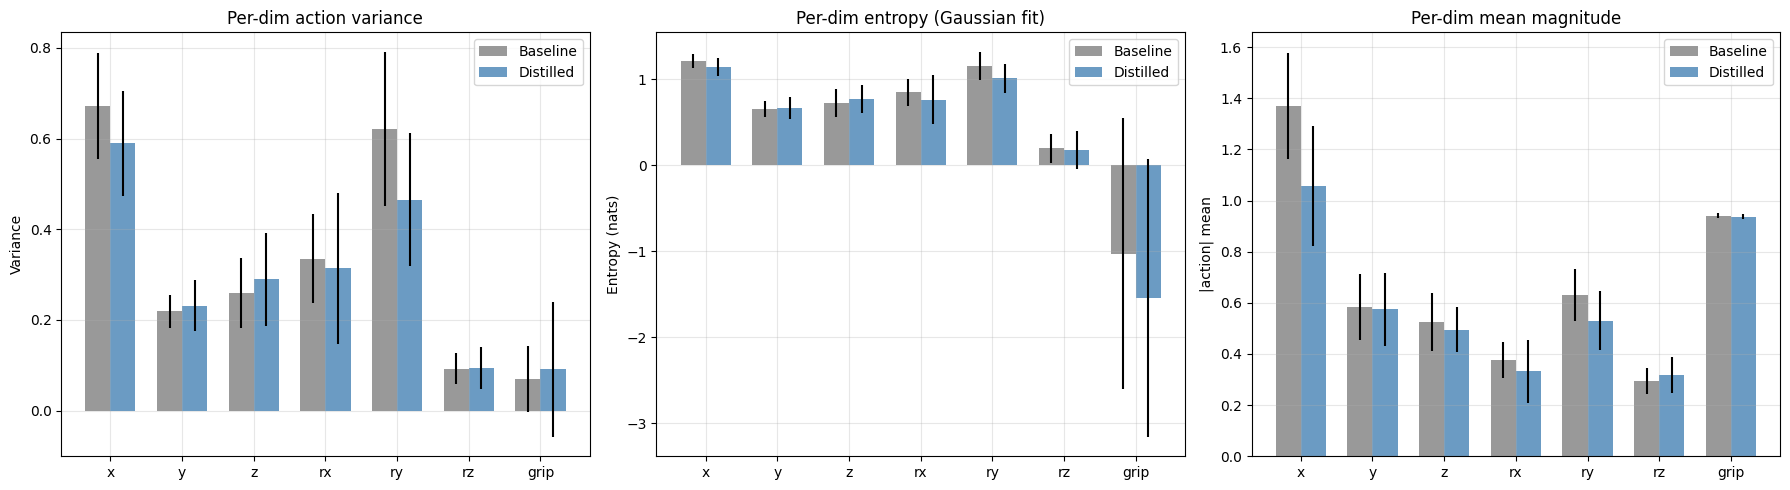

In [7]:
import matplotlib.pyplot as plt

dim_names = ["x", "y", "z", "rx", "ry", "rz", "grip"]

# Figure 1: per-dim variance and entropy comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Variance per dim
ax = axes[0]
x = np.arange(7)
w = 0.35
ax.bar(x - w/2, var_b_mean, w, yerr=var_b_std, label='Baseline', alpha=0.8, color='gray')
ax.bar(x + w/2, var_d_mean, w, yerr=var_d_std, label='Distilled', alpha=0.8, color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(dim_names)
ax.set_ylabel('Variance')
ax.set_title('Per-dim action variance')
ax.legend()
ax.grid(alpha=0.3)

# (b) Entropy per dim
ax = axes[1]
ax.bar(x - w/2, h_b_mean, w, yerr=h_b_std, label='Baseline', alpha=0.8, color='gray')
ax.bar(x + w/2, h_d_mean, w, yerr=h_d_std, label='Distilled', alpha=0.8, color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(dim_names)
ax.set_ylabel('Entropy (nats)')
ax.set_title('Per-dim entropy (Gaussian fit)')
ax.legend()
ax.grid(alpha=0.3)

# (c) Magnitude per dim
ax = axes[2]
ax.bar(x - w/2, mag_b_mean, w, yerr=mag_b_std, label='Baseline', alpha=0.8, color='gray')
ax.bar(x + w/2, mag_d_mean, w, yerr=mag_d_std, label='Distilled', alpha=0.8, color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(dim_names)
ax.set_ylabel('|action| mean')
ax.set_title('Per-dim mean magnitude')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/policy_comparison_perdim.png', dpi=100, bbox_inches='tight')
plt.show()


# Figure 2: Q-value distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(q_b_flat, bins=40, alpha=0.5, label='Baseline', color='gray', density=True)
ax.hist(q_d_flat, bins=40, alpha=0.5, label='Distilled', color='steelblue', density=True)
ax.axvline(q_b_flat.mean(), color='gray', linestyle='--', alpha=0.7)
ax.axvline(q_d_flat.mean(), color='steelblue', linestyle='--', alpha=0.7)
ax.set_xlabel('Q-value (twin min)')
ax.set_ylabel('Density')
ax.set_title(f'Q distribution — distill mean ↑ +{q_d_flat.mean()-q_b_flat.mean():.2f}')
ax.legend()
ax.grid(alpha=0.3)

# KL per dim
ax = axes[1]
ax.bar(x, kl_mean, yerr=kl_std, color='steelblue', alpha=0.8)
ax.axhline(0, color='k', alpha=0.3)
ax.set_xticks(x); ax.set_xticklabels(dim_names)
ax.set_ylabel('KL(distill || base)')
ax.set_title('Per-dim KL divergence')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/policy_comparison_qkl.png', dpi=100, bbox_inches='tight')
plt.show()


# Figure 3: Per-state pairwise diversity
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
state_ids = INIT_STATES_IDS
pair_b_per_state = np.array([r["pairwise_base"] for r in all_results])
pair_d_per_state = np.array([r["pairwise_distill"] for r in all_results])
ax.bar([str(s) for s in state_ids], pair_b_per_state, alpha=0.5, label='Baseline', color='gray')
ax.bar([str(s) for s in state_ids], pair_d_per_state, alpha=0.5, label='Distilled', color='steelblue')
ax.set_xlabel('init_state ID')
ax.set_ylabel('Mean pairwise L2 distance')
ax.set_title('Action diversity per state')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/policy_comparison_diversity.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nFigures saved to /mnt/user-data/outputs/")


## 8. Interpretation для отчёта

In [ ]:
print("="*80)
print("INTERPRETATION SUMMARY")
print("="*80)

# === 1. Did policy actually change? ===
total_kl = kl_mean.sum()
print(f"\n[1] Did distillation actually change policy?")
print(f"    Total KL(distill || base) = {total_kl:.3f}")
if total_kl > 1.0:
    print(f"    → YES, substantial shift. Distillation учила policy выдавать другие actions.")
elif total_kl > 0.2:
    print(f"    → MODERATE shift. Policy сместилась но не радикально.")
else:
    print(f"    → MINIMAL shift. Distillation почти не повлияла на distribution.")

# === 2. Did entropy decrease? ===
total_dh = (h_d_mean - h_b_mean).sum()
print(f"\n[2] Did entropy change?")
print(f"    ΔH total = {total_dh:+.3f}")
if total_dh < -0.3:
    print(f"    → DECREASED — policy became more deterministic (focused on Q-prefer-ed actions)")
elif total_dh > 0.3:
    print(f"    → INCREASED — policy became more exploratory")
else:
    print(f"    → ~SAME — entropy preserved by distillation")

# === 3. Did diversity decrease? ===
div_ratio = pair_d_mean / pair_b_mean
print(f"\n[3] Did action diversity change?")
print(f"    Pairwise distance ratio = {div_ratio:.2f}×")
if div_ratio < 0.9:
    print(f"    → REDUCED — distilled samples closer to each other (mode collapse signal)")
elif div_ratio > 1.1:
    print(f"    → INCREASED — distilled samples более разнообразны")
else:
    print(f"    → ~SAME — diversity preserved")

# === 4. Did Q-values improve? ===
dq = q_d_flat.mean() - q_b_flat.mean()
print(f"\n[4] Did sampled actions become more Q-prefer-able?")
print(f"    ΔQ mean = {dq:+.3f}")
if dq > 1.0:
    print(f"    → YES, distilled samples have higher Q (critic prefers their actions)")
    print(f"      → Strong evidence distillation absorbed critic preferences")
elif dq > 0.3:
    print(f"    → MARGINAL improvement в Q")
elif dq < -0.3:
    print(f"    → DEGRADED — distilled samples have LOWER Q (distillation broke something?)")
else:
    print(f"    → NO CHANGE — distillation не повлияла на Q-prefer-ence")

# === 5. Most affected dimensions ===
print(f"\n[5] Which action dims changed the most? (top by KL)")
sorted_idx = np.argsort(kl_mean)[::-1]
for i in sorted_idx[:3]:
    print(f"    {dim_names[i]}: KL={kl_mean[i]:.3f}, "
          f"Δmean={mean_d_mean[i] - mean_b_mean[i] if 'mean_b_mean' in dir() else (None):+.3f}, "
          f"Δvar={(var_d_mean[i] - var_b_mean[i])/var_b_mean[i]*100:+.1f}%")

# === 6. Gripper behavior shift ===
g_frac_b = np.mean(grip_b_flat > 0)
g_frac_d = np.mean(grip_d_flat > 0)
print(f"\n[6] Gripper behavior:")
print(f"    Baseline fraction close (g>0):   {g_frac_b:.2%}")
print(f"    Distilled fraction close (g>0):  {g_frac_d:.2%}")
print(f"    Δ = {(g_frac_d - g_frac_b)*100:+.1f}pp")


## 9. Report-ready findings

In [ ]:
print("="*80)
print("REPORT-READY METRICS TABLE")
print("="*80)

print(f"""
Table: Policy distribution comparison (baseline vs distilled), 13 states × 32 samples each

Metric                          Baseline             Distilled            Δ
─────────────────────────────────────────────────────────────────────────────
Action variance (mean)          {var_b_mean.mean():.4f}              {var_d_mean.mean():.4f}              {(var_d_mean.mean()-var_b_mean.mean())/var_b_mean.mean()*100:+.0f}%
Action entropy (sum nats)       {h_b_mean.sum():+.2f}              {h_d_mean.sum():+.2f}              {(h_d_mean-h_b_mean).sum():+.2f}
Inter-sample diversity (L2)     {pair_b_mean:.4f}              {pair_d_mean:.4f}              {(pair_d_mean-pair_b_mean)/pair_b_mean*100:+.0f}%
Q-value (mean)                  {q_b_flat.mean():+.2f}              {q_d_flat.mean():+.2f}              {q_d_flat.mean()-q_b_flat.mean():+.2f}
Gripper close fraction (g>0)    {np.mean(grip_b_flat > 0):.2%}                {np.mean(grip_d_flat > 0):.2%}                {(np.mean(grip_d_flat>0)-np.mean(grip_b_flat>0))*100:+.1f}pp
KL(distill || base) — total     —                    —                    {kl_mean.sum():.3f}
""")


# Save raw data for further analysis
import pickle
save_path = '/mnt/user-data/outputs/policy_comparison_raw.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'all_results': all_results,
        'aggregated': {
            'var_base_mean': var_b_mean, 'var_distill_mean': var_d_mean,
            'h_base_mean': h_b_mean, 'h_distill_mean': h_d_mean,
            'mag_base_mean': mag_b_mean, 'mag_distill_mean': mag_d_mean,
            'kl_per_dim': kl_mean,
            'pairwise_base': pair_b_mean, 'pairwise_distill': pair_d_mean,
            'q_base_flat': q_b_flat, 'q_distill_flat': q_d_flat,
            'grip_base_flat': grip_b_flat, 'grip_distill_flat': grip_d_flat,
        },
        'config': {
            'BASELINE_PATH': BASELINE_PATH,
            'DISTILLED_PATH': DISTILLED_PATH,
            'N_SAMPLES_PER_STATE': N_SAMPLES_PER_STATE,
            'INIT_STATES_IDS': INIT_STATES_IDS,
        }
    }, f)
print(f"Raw data saved to {save_path}")
